# Portuguese emigration, crises, and labour-law changes

This notebook examines annual Portuguese emigration outflows using the **Portuguese Emigration Observatory** series on total departures of Portuguese emigrants. The main objective is descriptive: to place the emigration series on a timeline that also marks major macroeconomic shocks and important labour-law reforms.

Two kinds of events are highlighted throughout the analysis:

1. **Economic crises and external shocks**, including the global financial crisis, the Portuguese sovereign-debt crisis and Troika programme, COVID-19, and the post-pandemic inflation and energy shock.
2. **Portuguese labour-law changes**, including the 2003 Labour Code, the 2009 Labour Code revision, the 2012 reform adopted during the adjustment period, the 2019 amendment, and the 2023 Decent Work Agenda.

## Main definition

The central series in this notebook is the **Observatory estimate of total Portuguese emigrant outflows**. This is not the same thing as net migration, and it is also not the same as the total stock of Portuguese-born people living abroad. It is an annual flow measure.

The latest complete annual table available on the Observatory page used here currently runs from **2000 to 2024**. Although the original request referred to the last 26 years, the public data presently supports the observed window **2000-2024**. The notebook is structured so the end year can be extended easily when newer data is published.


## Sources used in this notebook

The main empirical source is the **Portuguese Emigration Observatory**, specifically table **E.2 Estimates of total outflows of Portuguese emigrants, 2000-2024**. The Observatory notes that its total-flow estimates are based on Portuguese arrivals recorded in destination countries, whereas INE / Statistics Portugal relies on official Portuguese statistical series. That distinction matters later when the two series are compared.

The labour-law markers are based on the following legal changes:

- **Law no. 99/2003**, the first Portuguese Labour Code.
- **Law no. 7/2009**, a revision of the Labour Code.
- **Law no. 23/2012**, the labour-code reform adopted during the adjustment programme.
- **Law no. 93/2019**, amendments to the Labour Code and the contribution framework.
- **Law no. 13/2023**, the Decent Work Agenda, mostly in force from 1 May 2023.

The event lists below are kept as explicit Python dictionaries so the notebook remains transparent, auditable, and easy to extend.


### What this cell does

This opening code cell sets up the notebook environment. It imports the required libraries, defines the Observatory source URL, and fixes the analysis window through `START_YEAR` and `END_YEAR`. It also applies a few pandas display settings so that the tables shown later are easier to read.

In practice, this cell establishes the notebook's global configuration: if the source URL changes or a new year becomes available, this is one of the main places that needs updating.


In [1]:

from __future__ import annotations

import re
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup


SOURCE_URL: Final[str] = "https://observatorioemigracao.pt/np4EN/1315/"

# Change these when a newer year is published.
START_YEAR: Final[int] = 2000
END_YEAR: Final[int] = 2024

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)


C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


### What this cell does

This is the data-ingestion cell. It contains both the logic for scraping the Observatory page and a built-in fallback version of the E.2 table. The fallback matters because official websites change structure over time, and a notebook that depends only on live scraping is fragile.

The helper functions standardize the raw table into a clean dataframe:

- `_parse_number()` converts Observatory tokens into numeric values and treats `..` as missing data.
- `_fallback_frame()` converts the embedded fallback rows into the same structure expected from the live scrape.
- `load_emigration_data()` first attempts to read the Observatory page and only falls back when extraction fails.

The output of this step is the cleaned `emigration` dataframe used everywhere else in the notebook.


In [2]:

# Embedded fallback copied from the Portuguese Emigration Observatory table E.2.
# It is used only if live extraction fails or if the website structure changes.
EMIGRATION_FALLBACK: Final[list[dict[str, int | float | None]]] = [
    {"year": 2024, "ine_total": 80101, "ine_permanent": 33916, "ine_temporary": 46185, "oem_estimate": 65000},
    {"year": 2023, "ine_total": 81426, "ine_permanent": 33666, "ine_temporary": 47760, "oem_estimate": 70000},
    {"year": 2022, "ine_total": 71717, "ine_permanent": 30954, "ine_temporary": 40763, "oem_estimate": 70000},
    {"year": 2021, "ine_total": 65983, "ine_permanent": 25079, "ine_temporary": 40904, "oem_estimate": 65000},
    {"year": 2020, "ine_total": 68209, "ine_permanent": 25886, "ine_temporary": 42323, "oem_estimate": 45000},
    {"year": 2019, "ine_total": 77040, "ine_permanent": 28219, "ine_temporary": 48821, "oem_estimate": 80000},
    {"year": 2018, "ine_total": 81754, "ine_permanent": 31600, "ine_temporary": 50154, "oem_estimate": 75000},
    {"year": 2017, "ine_total": 81051, "ine_permanent": 31753, "ine_temporary": 49298, "oem_estimate": 80000},
    {"year": 2016, "ine_total": 97151, "ine_permanent": 38273, "ine_temporary": 58878, "oem_estimate": 95000},
    {"year": 2015, "ine_total": 101203, "ine_permanent": 40377, "ine_temporary": 60826, "oem_estimate": 105000},
    {"year": 2014, "ine_total": 134624, "ine_permanent": 49572, "ine_temporary": 85052, "oem_estimate": 110000},
    {"year": 2013, "ine_total": 128108, "ine_permanent": 53786, "ine_temporary": 74322, "oem_estimate": 120000},
    {"year": 2012, "ine_total": 121418, "ine_permanent": 51958, "ine_temporary": 69460, "oem_estimate": 105000},
    {"year": 2011, "ine_total": 100978, "ine_permanent": 43998, "ine_temporary": 56980, "oem_estimate": 85000},
    {"year": 2010, "ine_total": None, "ine_permanent": 23760, "ine_temporary": None, "oem_estimate": 65000},
    {"year": 2009, "ine_total": None, "ine_permanent": 16899, "ine_temporary": None, "oem_estimate": 70000},
    {"year": 2008, "ine_total": None, "ine_permanent": 20357, "ine_temporary": None, "oem_estimate": 85000},
    {"year": 2007, "ine_total": None, "ine_permanent": 7890, "ine_temporary": None, "oem_estimate": 85000},
    {"year": 2006, "ine_total": None, "ine_permanent": 5600, "ine_temporary": None, "oem_estimate": 75000},
    {"year": 2005, "ine_total": None, "ine_permanent": 6360, "ine_temporary": None, "oem_estimate": 65000},
    {"year": 2004, "ine_total": None, "ine_permanent": 6757, "ine_temporary": None, "oem_estimate": 70000},
    {"year": 2003, "ine_total": 27008, "ine_permanent": 6687, "ine_temporary": 20321, "oem_estimate": 60000},
    {"year": 2002, "ine_total": 27358, "ine_permanent": 8813, "ine_temporary": 18545, "oem_estimate": 50000},
    {"year": 2001, "ine_total": 20223, "ine_permanent": 5396, "ine_temporary": 14827, "oem_estimate": 40000},
    {"year": 2000, "ine_total": 21333, "ine_permanent": 4692, "ine_temporary": 16641, "oem_estimate": None},
]


def _parse_number(token: str) -> int | None:
    """Parse Observatory number tokens, including '..' as missing."""
    if not isinstance(token, str):
        raise TypeError(f"token must be str, got {type(token)!r}")

    token = token.strip().replace(",", "")
    if token == "..":
        return None

    if not token.isdigit():
        raise ValueError(f"Invalid numeric token: {token!r}")

    return int(token)


def _fallback_frame() -> pd.DataFrame:
    """Return the embedded fallback data as a clean DataFrame."""
    df = pd.DataFrame(EMIGRATION_FALLBACK)
    return (
        df.sort_values("year")
        .query("@START_YEAR <= year <= @END_YEAR")
        .reset_index(drop=True)
    )


def load_emigration_data(source_url: str = SOURCE_URL, timeout_seconds: int = 30) -> pd.DataFrame:
    """
    Load total Portuguese emigrant outflow estimates from the Observatory page.

    The scraper reads the plain text around table E.2 and extracts rows for 2000-2024.
    If extraction fails, it falls back to the embedded table above.

    Parameters
    ----------
    source_url:
        URL of the Portuguese Emigration Observatory global estimates page.
    timeout_seconds:
        HTTP timeout in seconds.

    Returns
    -------
    pd.DataFrame
        DataFrame with year, INE total/permanent/temporary values, and the Observatory estimate.
    """
    if not isinstance(source_url, str):
        raise TypeError("source_url must be a string.")
    if not isinstance(timeout_seconds, int) or timeout_seconds <= 0:
        raise ValueError("timeout_seconds must be a positive integer.")

    try:
        response = requests.get(source_url, timeout=timeout_seconds)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        text = soup.get_text("\n")

        start = text.find("E.2")
        end = text.find("E.3", start)
        if start == -1 or end == -1:
            raise ValueError("Could not locate E.2/E.3 text boundaries.")

        chunk = text[start:end]

        # Tokens include years, numbers such as 80,101, and missing values '..'.
        tokens = re.findall(r"\d{4}|\d{1,3}(?:,\d{3})*|\.\.", chunk)

        rows: list[dict[str, int | None]] = []
        expected_years = list(range(2024, 1999, -1))
        position = 0

        for expected_year in expected_years:
            while position < len(tokens) and tokens[position] != str(expected_year):
                position += 1

            if position >= len(tokens):
                raise ValueError(f"Year {expected_year} not found in parsed tokens.")

            row_tokens = tokens[position : position + 5]
            if len(row_tokens) < 5:
                raise ValueError(f"Incomplete row for year {expected_year}: {row_tokens}")

            year, ine_total, ine_permanent, ine_temporary, oem_estimate = row_tokens

            rows.append(
                {
                    "year": int(year),
                    "ine_total": _parse_number(ine_total),
                    "ine_permanent": _parse_number(ine_permanent),
                    "ine_temporary": _parse_number(ine_temporary),
                    "oem_estimate": _parse_number(oem_estimate),
                }
            )
            position += 5

        df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

        required_columns = {"year", "ine_total", "ine_permanent", "ine_temporary", "oem_estimate"}
        if set(df.columns) != required_columns:
            raise ValueError("Parsed data does not have the expected columns.")

        if df["year"].min() > START_YEAR or df["year"].max() < END_YEAR:
            raise ValueError("Parsed data does not cover the requested period.")

        return df.query("@START_YEAR <= year <= @END_YEAR").reset_index(drop=True)

    except Exception as exc:
        print(f"Live extraction failed: {exc}")
        print("Using embedded fallback data.")
        return _fallback_frame()


emigration = load_emigration_data()
emigration["oem_yoy_change_pct"] = emigration["oem_estimate"].pct_change() * 100
emigration["ine_total_yoy_change_pct"] = emigration["ine_total"].pct_change() * 100

emigration.head(), emigration.tail()


C:\Users\diogo\AppData\Local\Temp\ipykernel_33196\2913444083.py:145: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  emigration["ine_total_yoy_change_pct"] = emigration["ine_total"].pct_change() * 100


(   year  ine_total  ine_permanent  ine_temporary  oem_estimate  \
 0  2000  21,333.00           4692      16,641.00           NaN   
 1  2001  20,223.00           5396      14,827.00     40,000.00   
 2  2002  27,358.00           8813      18,545.00     50,000.00   
 3  2003  27,008.00           6687      20,321.00     60,000.00   
 4  2004        NaN           6757            NaN     70,000.00   
 
    oem_yoy_change_pct  ine_total_yoy_change_pct  
 0                 NaN                       NaN  
 1                 NaN                     -5.20  
 2               25.00                     35.28  
 3               20.00                     -1.28  
 4               16.67                      0.00  ,
     year  ine_total  ine_permanent  ine_temporary  oem_estimate  \
 20  2020  68,209.00          25886      42,323.00     45,000.00   
 21  2021  65,983.00          25079      40,904.00     65,000.00   
 22  2022  71,717.00          30954      40,763.00     70,000.00   
 23  2023  81,426

### What this cell does

This cell creates two small event tables that provide the interpretive structure for the plots.

- `crises` groups broad macroeconomic shock periods that may plausibly affect emigration dynamics.
- `labour_events` lists the major labour-law reforms that the user asked to place on the same time axis.

The point is not to prove that these events caused the observed changes. The point is to make the timeline legible and to give the reader explicit reference points for later interpretation.


In [3]:

CRISES: Final[list[dict[str, int | str]]] = [
    {
        "start_year": 2001,
        "end_year": 2002,
        "label": "Dot-com and 9/11 shock",
        "notes": "Global slowdown. Included as context, not as a Portugal-specific emigration cause.",
    },
    {
        "start_year": 2008,
        "end_year": 2009,
        "label": "Global financial crisis",
        "notes": "International financial crisis and recessionary shock.",
    },
    {
        "start_year": 2011,
        "end_year": 2014,
        "label": "Portugal bailout and Troika programme",
        "notes": "Portugal requested EU/IMF assistance in April 2011; adjustment programme ran through 2014.",
    },
    {
        "start_year": 2020,
        "end_year": 2021,
        "label": "COVID-19 shock",
        "notes": "Pandemic and restrictions; emigration flows are also affected by mobility restrictions.",
    },
    {
        "start_year": 2022,
        "end_year": 2023,
        "label": "Inflation and energy shock",
        "notes": "Post-pandemic inflation and energy-price shock after Russia's invasion of Ukraine.",
    },
]

LABOUR_LAW_EVENTS: Final[list[dict[str, str | int]]] = [
    {
        "year": 2003,
        "date": "2003-08-27",
        "law": "Law no. 99/2003",
        "label": "2003 Labour Code",
        "notes": "First Portuguese Labour Code.",
    },
    {
        "year": 2009,
        "date": "2009-02-12",
        "law": "Law no. 7/2009",
        "label": "2009 Labour Code revision",
        "notes": "Revision of the Labour Code.",
    },
    {
        "year": 2012,
        "date": "2012-06-25",
        "law": "Law no. 23/2012",
        "label": "2012 labour reform",
        "notes": "Major labour-code reform during the adjustment period.",
    },
    {
        "year": 2019,
        "date": "2019-09-04",
        "law": "Law no. 93/2019",
        "label": "2019 Labour Code amendment",
        "notes": "Amended the Labour Code, regulation, and social-security contribution code.",
    },
    {
        "year": 2023,
        "date": "2023-04-03",
        "law": "Law no. 13/2023",
        "label": "2023 Decent Work Agenda",
        "notes": "Wide-ranging labour-law changes, mostly in force from 1 May 2023.",
    },
]

crises = pd.DataFrame(CRISES)
labour_events = pd.DataFrame(LABOUR_LAW_EVENTS)

display(crises)
display(labour_events)


,start_year,end_year,label,notes
0,2001,2002,Dot-com and 9/11 shock,"Global slowdown. Included as context, not as a..."
1,2008,2009,Global financial crisis,International financial crisis and recessionar...
2,2011,2014,Portugal bailout and Troika programme,Portugal requested EU/IMF assistance in April ...
3,2020,2021,COVID-19 shock,Pandemic and restrictions; emigration flows ar...
4,2022,2023,Inflation and energy shock,Post-pandemic inflation and energy-price shock...


,year,date,law,label,notes
0,2003,2003-08-27,Law no. 99/2003,2003 Labour Code,First Portuguese Labour Code.
1,2009,2009-02-12,Law no. 7/2009,2009 Labour Code revision,Revision of the Labour Code.
2,2012,2012-06-25,Law no. 23/2012,2012 labour reform,Major labour-code reform during the adjustment...
3,2019,2019-09-04,Law no. 93/2019,2019 Labour Code amendment,"Amended the Labour Code, regulation, and socia..."
4,2023,2023-04-03,Law no. 13/2023,2023 Decent Work Agenda,"Wide-ranging labour-law changes, mostly in for..."


### What this cell does

Before moving into the charts, this cell summarizes the series numerically. It calculates a few headline metrics such as the first and last year with Observatory estimates, cumulative outflows, the average annual estimate, and the peak year. It also prints the years with the largest annual outflows.

This is useful because it anchors the rest of the notebook in a few simple facts before the more visual timeline analysis begins.


In [4]:

def summarize_emigration(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a compact summary table for the main emigration series.

    Parameters
    ----------
    df:
        Emigration DataFrame returned by load_emigration_data().

    Returns
    -------
    pd.DataFrame
        Summary metrics.
    """
    required_columns = {"year", "oem_estimate", "ine_total"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    observed = df.dropna(subset=["oem_estimate"]).copy()
    peak_row = observed.loc[observed["oem_estimate"].idxmax()]

    summary = pd.DataFrame(
        [
            {"metric": "First year with Observatory estimate", "value": int(observed["year"].min())},
            {"metric": "Last year with Observatory estimate", "value": int(observed["year"].max())},
            {"metric": "Cumulative Observatory-estimated outflows", "value": int(observed["oem_estimate"].sum())},
            {"metric": "Average annual Observatory-estimated outflows", "value": int(round(observed["oem_estimate"].mean()))},
            {"metric": "Peak Observatory-estimated year", "value": int(peak_row["year"])},
            {"metric": "Peak Observatory-estimated outflow", "value": int(peak_row["oem_estimate"])},
        ]
    )
    return summary


summary = summarize_emigration(emigration)
display(summary)

top_years = (
    emigration.dropna(subset=["oem_estimate"])
    .sort_values("oem_estimate", ascending=False)
    .head(10)
    [["year", "oem_estimate", "ine_total", "ine_permanent", "ine_temporary"]]
)

display(top_years)


,metric,value
0,First year with Observatory estimate,2001
1,Last year with Observatory estimate,2024
2,Cumulative Observatory-estimated outflows,1835000
3,Average annual Observatory-estimated outflows,76458
4,Peak Observatory-estimated year,2013
5,Peak Observatory-estimated outflow,120000


,year,oem_estimate,ine_total,ine_permanent,ine_temporary
13,2013,"120,000.00","128,108.00",53786,"74,322.00"
14,2014,"110,000.00","134,624.00",49572,"85,052.00"
15,2015,"105,000.00","101,203.00",40377,"60,826.00"
12,2012,"105,000.00","121,418.00",51958,"69,460.00"
16,2016,"95,000.00","97,151.00",38273,"58,878.00"
7,2007,"85,000.00",NaN,7890,NaN
11,2011,"85,000.00","100,978.00",43998,"56,980.00"
8,2008,"85,000.00",NaN,20357,NaN
19,2019,"80,000.00","77,040.00",28219,"48,821.00"
17,2017,"80,000.00","81,051.00",31753,"49,298.00"


### What this cell does

This cell defines the reusable plotting helpers used throughout the notebook. Instead of rewriting the same formatting logic for every chart, the notebook centralizes it here:

- crisis periods are shown as shaded spans;
- labour-law reforms are shown as vertical marker lines;
- common axis formatting is handled in one place.

That makes the later plotting cells shorter and also ensures the visual language stays consistent across figures.


In [5]:

def add_crisis_spans(ax: plt.Axes, crises_df: pd.DataFrame) -> None:
    """Add shaded spans for crisis periods."""
    for row in crises_df.itertuples(index=False):
        ax.axvspan(row.start_year - 0.5, row.end_year + 0.5, alpha=0.12)
        ax.text(
            x=(row.start_year + row.end_year) / 2,
            y=0.98,
            s=row.label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
            rotation=90 if row.end_year == row.start_year else 0,
        )


def add_labour_law_lines(ax: plt.Axes, events_df: pd.DataFrame) -> None:
    """Add vertical lines for labour-law changes."""
    for row in events_df.itertuples(index=False):
        ax.axvline(row.year, linestyle="--", linewidth=1.0, alpha=0.75)
        ax.text(
            x=row.year + 0.08,
            y=0.02,
            s=row.label,
            transform=ax.get_xaxis_transform(),
            ha="left",
            va="bottom",
            fontsize=8,
            rotation=90,
        )


def finalize_time_axis(ax: plt.Axes, title: str, ylabel: str) -> None:
    """Apply common formatting to annual time-series plots."""
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left")


### What this chart shows

This first chart is the notebook's core visual. It plots the Observatory estimate of total Portuguese emigrant outflows and places that series on top of the crisis timeline and the labour-law timeline.

The chart should be read primarily as a historical overview. It makes it easy to see the broad surge in emigration during the sovereign-debt and adjustment years, but it should not be read as evidence that any single marked event mechanically caused the change.


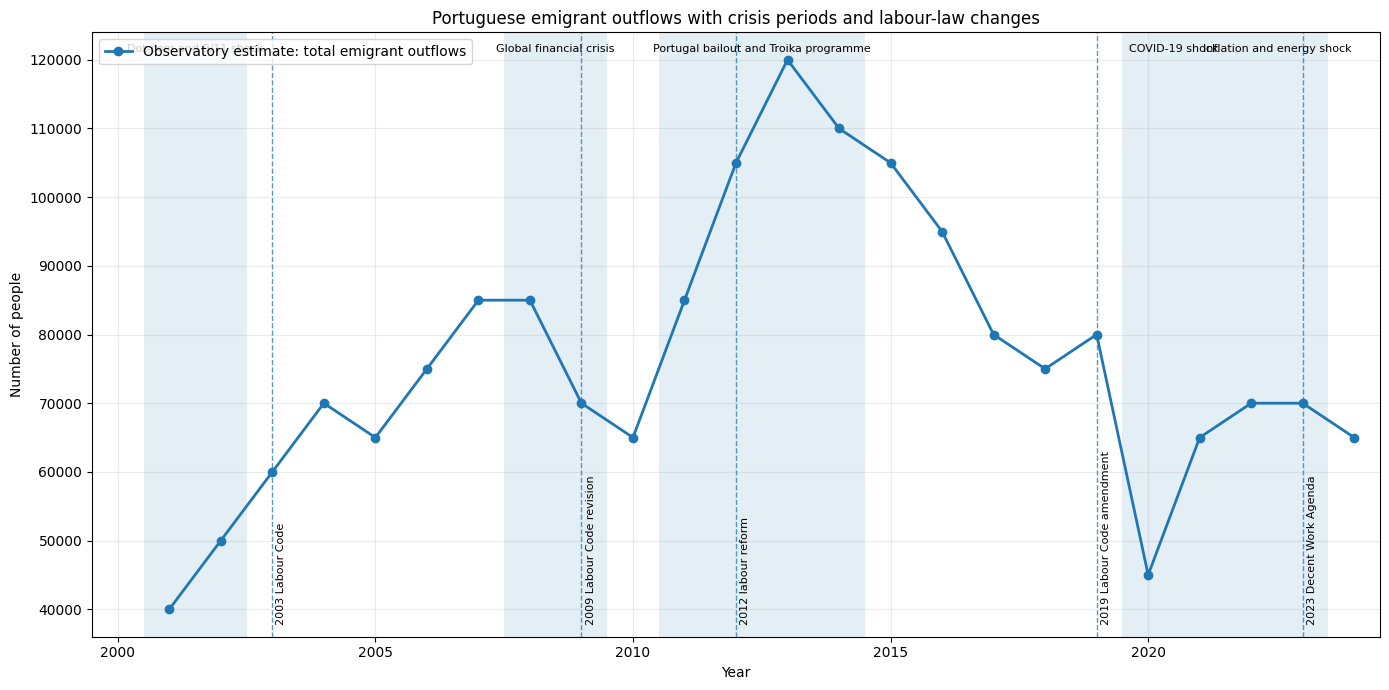

In [6]:

fig, ax = plt.subplots(figsize=(14, 7))

add_crisis_spans(ax, crises)
add_labour_law_lines(ax, labour_events)

ax.plot(
    emigration["year"],
    emigration["oem_estimate"],
    marker="o",
    linewidth=2,
    label="Observatory estimate: total emigrant outflows",
)

finalize_time_axis(
    ax=ax,
    title="Portuguese emigrant outflows with crisis periods and labour-law changes",
    ylabel="Number of people",
)

plt.tight_layout()
plt.show()


### What this chart shows

This figure compares the Observatory estimate with the INE total-outflow series. The comparison is important because readers often assume there is one single official emigration number, when in fact related sources can differ because they are built from different statistical procedures.

The value of this comparison is interpretive rather than adversarial: it shows where the two sources move together, where they diverge, and why differences in level or timing should not automatically be treated as contradictions.


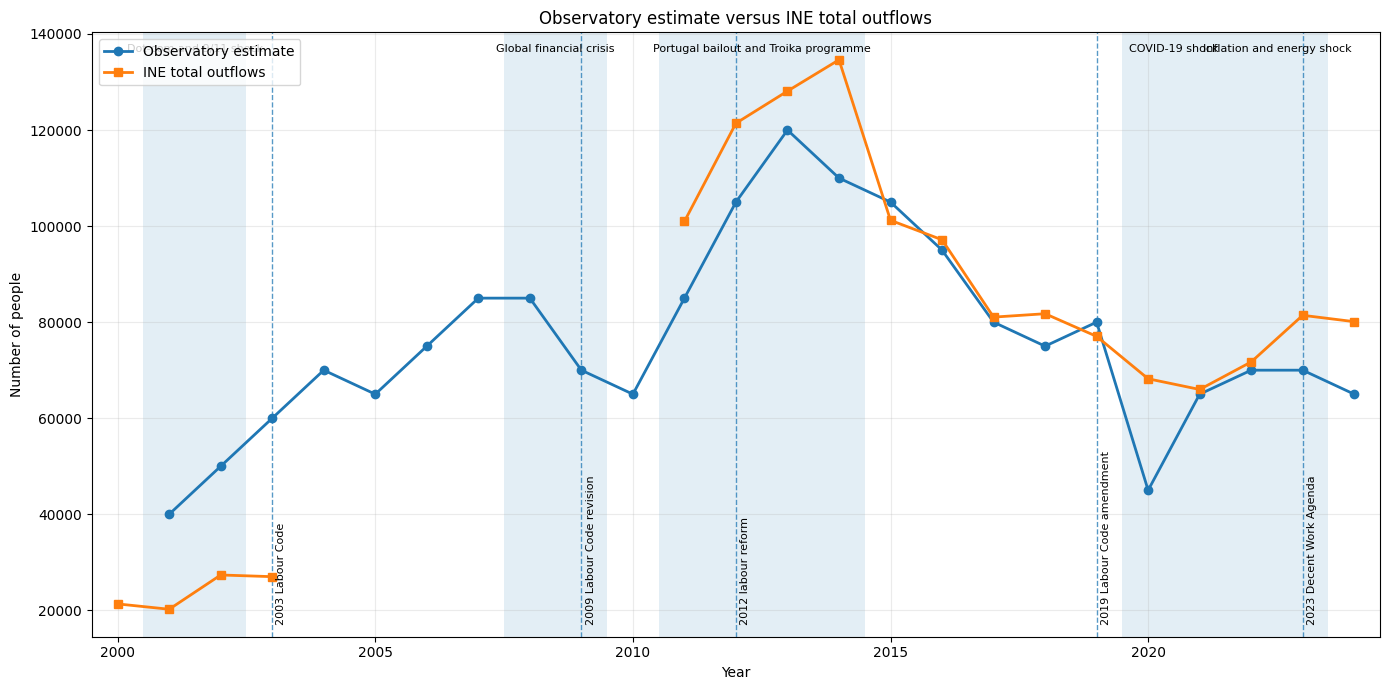

In [7]:

fig, ax = plt.subplots(figsize=(14, 7))

add_crisis_spans(ax, crises)
add_labour_law_lines(ax, labour_events)

ax.plot(
    emigration["year"],
    emigration["oem_estimate"],
    marker="o",
    linewidth=2,
    label="Observatory estimate",
)

ax.plot(
    emigration["year"],
    emigration["ine_total"],
    marker="s",
    linewidth=2,
    label="INE total outflows",
)

finalize_time_axis(
    ax=ax,
    title="Observatory estimate versus INE total outflows",
    ylabel="Number of people",
)

plt.tight_layout()
plt.show()


### What this chart shows

This figure separates the INE outflow series into permanent and temporary emigration. That distinction matters because a rise in total outflows can reflect different underlying patterns: a lasting relocation abroad, a shorter-term mobility episode, or a mix of the two.

Looking at the split prevents the total series from being treated as if it were homogeneous.


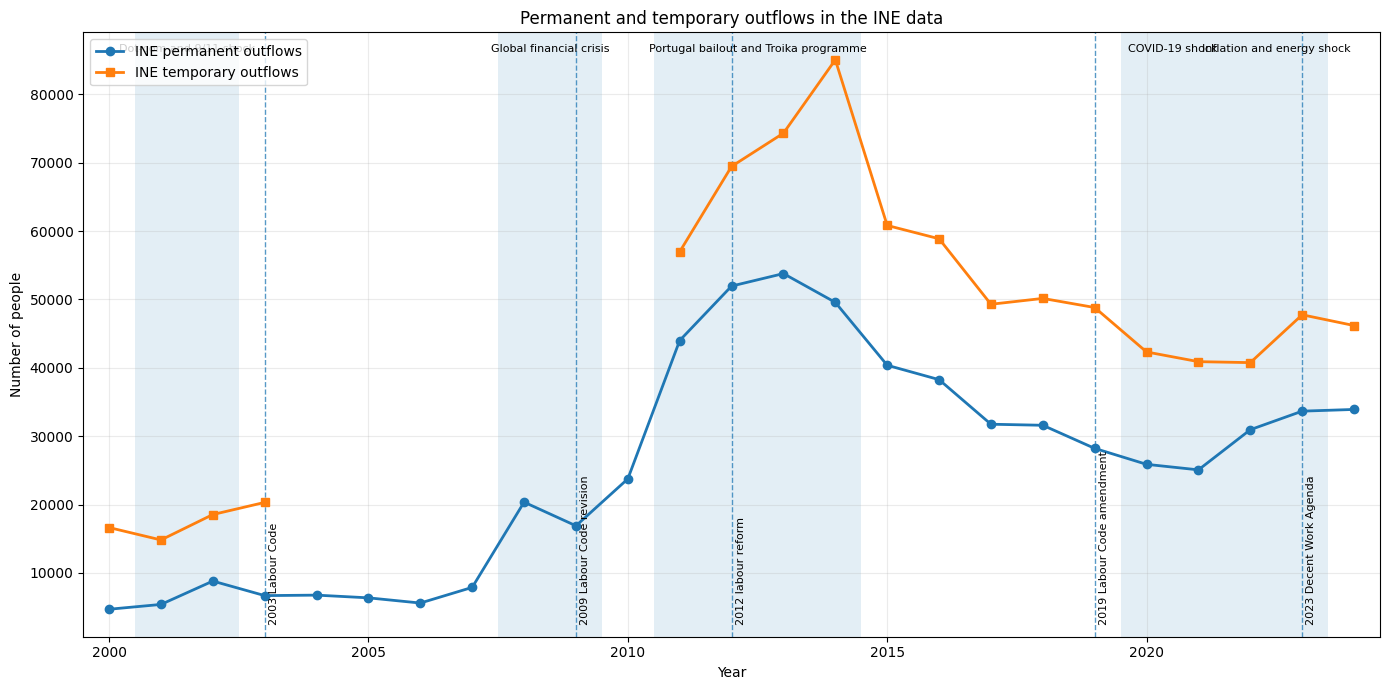

In [8]:

fig, ax = plt.subplots(figsize=(14, 7))

add_crisis_spans(ax, crises)
add_labour_law_lines(ax, labour_events)

ax.plot(
    emigration["year"],
    emigration["ine_permanent"],
    marker="o",
    linewidth=2,
    label="INE permanent outflows",
)

ax.plot(
    emigration["year"],
    emigration["ine_temporary"],
    marker="s",
    linewidth=2,
    label="INE temporary outflows",
)

finalize_time_axis(
    ax=ax,
    title="Permanent and temporary outflows in the INE data",
    ylabel="Number of people",
)

plt.tight_layout()
plt.show()


### What this chart shows

This figure changes the perspective from levels to annual variation. Instead of asking how many people left in a given year, it asks how sharply the estimated flow rose or fell relative to the previous year.

That makes turning points easier to detect, especially around crisis years, the adjustment period, and the post-COVID normalization.


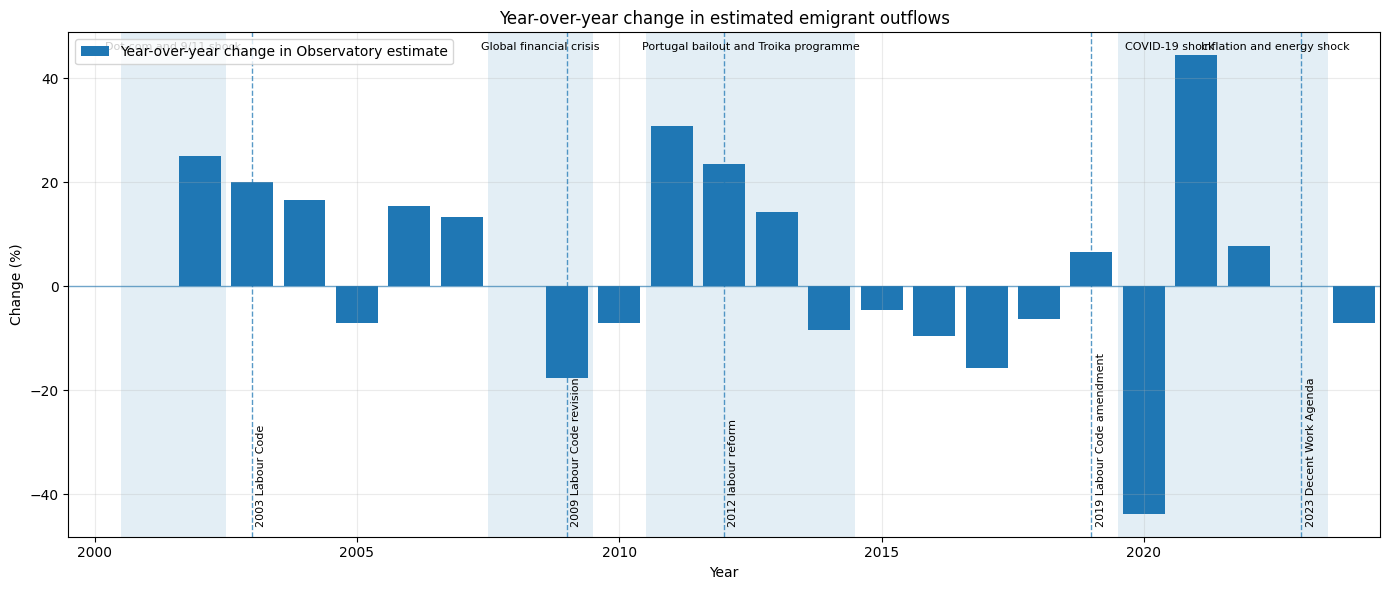

In [9]:

fig, ax = plt.subplots(figsize=(14, 6))

add_crisis_spans(ax, crises)
add_labour_law_lines(ax, labour_events)

ax.axhline(0, linewidth=1, alpha=0.6)
ax.bar(
    emigration["year"],
    emigration["oem_yoy_change_pct"],
    label="Year-over-year change in Observatory estimate",
)

finalize_time_axis(
    ax=ax,
    title="Year-over-year change in estimated emigrant outflows",
    ylabel="Change (%)",
)

plt.tight_layout()
plt.show()


## Reading the main plots

The clearest pattern in the notebook is the strong rise in emigration during the sovereign-debt crisis and adjustment period. In the Observatory estimate, the peak arrives in **2013**, at roughly **120,000** emigrants. In the INE total-outflow series, the highest value appears in **2014**, at **134,624** outflows.

After that peak phase, the series recedes from the exceptionally high 2013-2016 levels. The COVID-19 years should be treated with caution because mobility restrictions affected the practical ability to move abroad, not only economic incentives. By 2021-2024, the Observatory series settles into a lower but still elevated range, roughly **65,000 to 70,000** per year.

The labour-law markers should be interpreted as chronological reference points, not as causal findings. A serious causal design would need additional covariates such as unemployment, youth unemployment, wages, GDP growth, housing costs, and demand conditions in major destination countries.


### What this cell does

This cell exports the cleaned emigration series and the two event tables to CSV files. That makes the notebook easier to reuse outside Jupyter, whether for presentations, dashboards, follow-up modelling, or archival documentation.


In [10]:

# Optional export of the cleaned data and event tables.
OUTPUT_DIR = "outputs"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

emigration.to_csv(f"{OUTPUT_DIR}/emigration_outflows_portugal_2000_2024.csv", index=False)
crises.to_csv(f"{OUTPUT_DIR}/emigration_context_crisis_events.csv", index=False)
labour_events.to_csv(f"{OUTPUT_DIR}/emigration_context_labour_law_events.csv", index=False)

print(f"Exported CSV files to: {OUTPUT_DIR}/")


Exported CSV files to: outputs/


## Additional analyses

The next section extends the notebook beyond the original descriptive figures. The aim is still interpretive rather than causal, but these extra views help the reader think more clearly about underlying trend, phase changes, and event timing.


### Extension 1: smoothing the annual series

Annual emigration flows can be noisy. A short moving average helps distinguish medium-term direction from one-year volatility.

This extension does not replace the raw series. It adds a smoother reference line so the reader can judge whether a visible spike is a brief fluctuation or part of a broader shift.


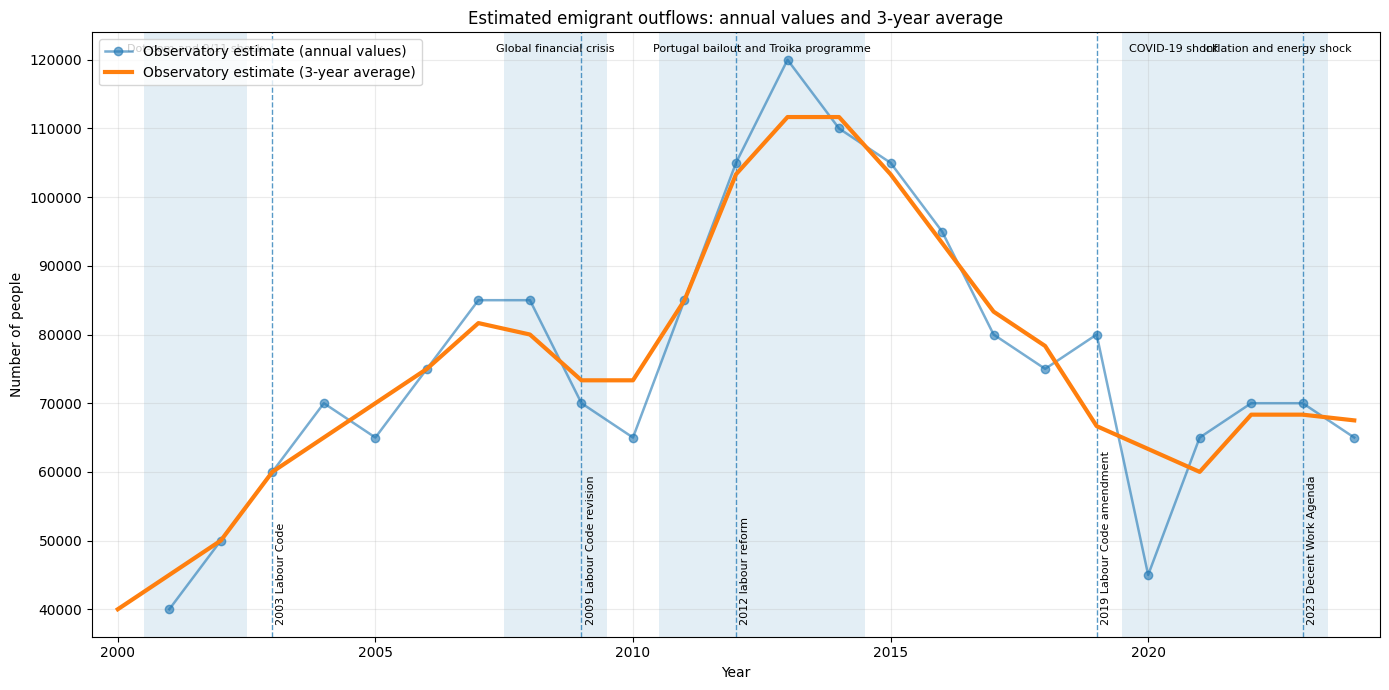

In [11]:
emigration["oem_3y_ma"] = (
    emigration["oem_estimate"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 7))

add_crisis_spans(ax, crises)
add_labour_law_lines(ax, labour_events)

ax.plot(
    emigration["year"],
    emigration["oem_estimate"],
    marker="o",
    linewidth=1.8,
    alpha=0.6,
    label="Observatory estimate (annual values)",
)
ax.plot(
    emigration["year"],
    emigration["oem_3y_ma"],
    linewidth=3,
    label="Observatory estimate (3-year average)",
)

finalize_time_axis(
    ax=ax,
    title="Estimated emigrant outflows: annual values and 3-year average",
    ylabel="Number of people",
)

plt.tight_layout()
plt.show()

### Extension 2: comparing broad historical phases

This extension aggregates the annual series into broader historical periods. That makes it easier to compare the pre-crisis years, the financial-crisis phase, the Troika period, the post-adjustment years, the COVID shock, and the more recent post-COVID period.

The goal is simple: show whether the crisis years look unusually elevated not just visually, but also in average and cumulative terms.


In [12]:
PERIODS = [
    {"period": "2000-2007 pre-financial-crisis", "start_year": 2000, "end_year": 2007},
    {"period": "2008-2010 global-financial-crisis phase", "start_year": 2008, "end_year": 2010},
    {"period": "2011-2014 Troika / adjustment period", "start_year": 2011, "end_year": 2014},
    {"period": "2015-2019 post-adjustment normalization", "start_year": 2015, "end_year": 2019},
    {"period": "2020-2021 COVID shock", "start_year": 2020, "end_year": 2021},
    {"period": "2022-2024 post-COVID / inflation shock", "start_year": 2022, "end_year": 2024},
]

period_rows = []
for period in PERIODS:
    subset = emigration.loc[
        emigration["year"].between(period["start_year"], period["end_year"])
        & emigration["oem_estimate"].notna()
    ].copy()

    period_rows.append(
        {
            "period": period["period"],
            "years": len(subset),
            "average_oem_estimate": round(subset["oem_estimate"].mean(), 1),
            "min_oem_estimate": int(subset["oem_estimate"].min()),
            "max_oem_estimate": int(subset["oem_estimate"].max()),
            "cumulative_oem_estimate": int(subset["oem_estimate"].sum()),
        }
    )

period_summary = pd.DataFrame(period_rows)
display(period_summary)

,period,years,average_oem_estimate,min_oem_estimate,max_oem_estimate,cumulative_oem_estimate
0,2000-2007 pre-financial-crisis,7,"63,571.40",40000,85000,445000
1,2008-2010 global-financial-crisis phase,3,"73,333.30",65000,85000,220000
2,2011-2014 Troika / adjustment period,4,"105,000.00",85000,120000,420000
3,2015-2019 post-adjustment normalization,5,"87,000.00",75000,105000,435000
4,2020-2021 COVID shock,2,"55,000.00",45000,65000,110000
5,2022-2024 post-COVID / inflation shock,3,"68,333.30",65000,70000,205000


### Extension 3: pre/post windows around labour-law reforms

This extension adds a simple event-window summary around each labour-law change. For each reform year, it compares the average emigration estimate in the two years before the law, the level in the event year itself, and the average in the two years after.

This remains a descriptive device, not a formal event-study design, but it gives the reader a more disciplined way to inspect whether a reform coincided with a visible break in the series.


In [13]:
def labour_event_window_summary(
    emigration_df: pd.DataFrame,
    events_df: pd.DataFrame,
    window: int = 2,
) -> pd.DataFrame:
    """Summarize pre/post windows around labour-law events."""
    rows = []
    for row in events_df.itertuples(index=False):
        before = emigration_df.loc[
            emigration_df["year"].between(row.year - window, row.year - 1),
            "oem_estimate",
        ].dropna()
        after = emigration_df.loc[
            emigration_df["year"].between(row.year + 1, row.year + window),
            "oem_estimate",
        ].dropna()
        event_value = emigration_df.loc[
            emigration_df["year"] == row.year,
            "oem_estimate",
        ].dropna()

        rows.append(
            {
                "law": row.law,
                "label": row.label,
                "event_year": int(row.year),
                "avg_before_2y": round(before.mean(), 1) if not before.empty else None,
                "event_year_value": int(event_value.iloc[0]) if not event_value.empty else None,
                "avg_after_2y": round(after.mean(), 1) if not after.empty else None,
                "avg_after_minus_before": round(after.mean() - before.mean(), 1)
                if not before.empty and not after.empty
                else None,
            }
        )

    return pd.DataFrame(rows)


labour_event_windows = labour_event_window_summary(emigration, labour_events, window=2)
display(labour_event_windows)

,law,label,event_year,avg_before_2y,event_year_value,avg_after_2y,avg_after_minus_before
0,Law no. 99/2003,2003 Labour Code,2003,"45,000.00",60000,"67,500.00","22,500.00"
1,Law no. 7/2009,2009 Labour Code revision,2009,"85,000.00",70000,"75,000.00","-10,000.00"
2,Law no. 23/2012,2012 labour reform,2012,"75,000.00",105000,"115,000.00","40,000.00"
3,Law no. 93/2019,2019 Labour Code amendment,2019,"77,500.00",80000,"55,000.00","-22,500.00"
4,Law no. 13/2023,2023 Decent Work Agenda,2023,"67,500.00",70000,"65,000.00","-2,500.00"


## Reading the extensions

These extra outputs make the notebook more informative in three ways:

- the moving average clarifies the medium-term trend;
- the period summary shows how exceptional the adjustment years were in comparative terms;
- the event-window table makes the labour-law timeline easier to inspect systematically.

Even so, the notebook remains a descriptive analysis. Stronger claims would require richer explanatory variables and a clearer identification strategy.


## Further extensions

This notebook can be pushed further in several directions.

1. Add macroeconomic controls such as unemployment, youth unemployment, real wages, GDP growth, inflation, and housing-cost indicators.
2. Compare Portuguese emigration with labour-market demand in major destination countries such as Spain, France, Switzerland, Luxembourg, the United Kingdom, and Germany.
3. Move from descriptive analysis to modelling with approaches such as interrupted time-series models, Bayesian structural time series, event-study designs, change-point detection, or synthetic-control style comparisons.
4. Disaggregate the flows by type, age group, education level, or destination country.

Those additions would move the notebook closer to an explanatory research design rather than a structured descriptive report.
